In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [2]:
from utils.plot_style import set_plot_style

In [3]:
# Grid
N = 800
lim = 2.0
g = np.linspace(-lim, lim, N)
G1, G2 = np.meshgrid(g, g)
product = G1 * G2

In [4]:
# Special cavity configurations: label -> (g1, g2, color, marker)
configs = {
    "confocal\n$(0,0)$":          ( 0,  0, "#e05c2a", "D"),
    "plane-plane\n$(1,1)$":       ( 1,  1, "#e05c2a", "o"),
    "concentric\n$(-1,-1)$":      (-1, -1, "#e05c2a", "o"),
    "hemispherical\n$(1,0)$":     ( 1,  0, "#2a7ae0", "s"),
    "hemispherical\n$(0,1)$":     ( 0,  1, "#2a7ae0", "s"),
}

# Manual annotation offsets (dx, dy) in data units
offsets = {
    "confocal\n$(0,0)$":          ( 0.28, -0.18),
    "plane-plane\n$(1,1)$":       ( 0.52,  0.52),
    "concentric\n$(-1,-1)$":      (-0.52, -0.52),
    "hemispherical\n$(1,0)$":     ( 0.38, -0.18),
    "hemispherical\n$(0,1)$":     (-0.38,  0.18),
}

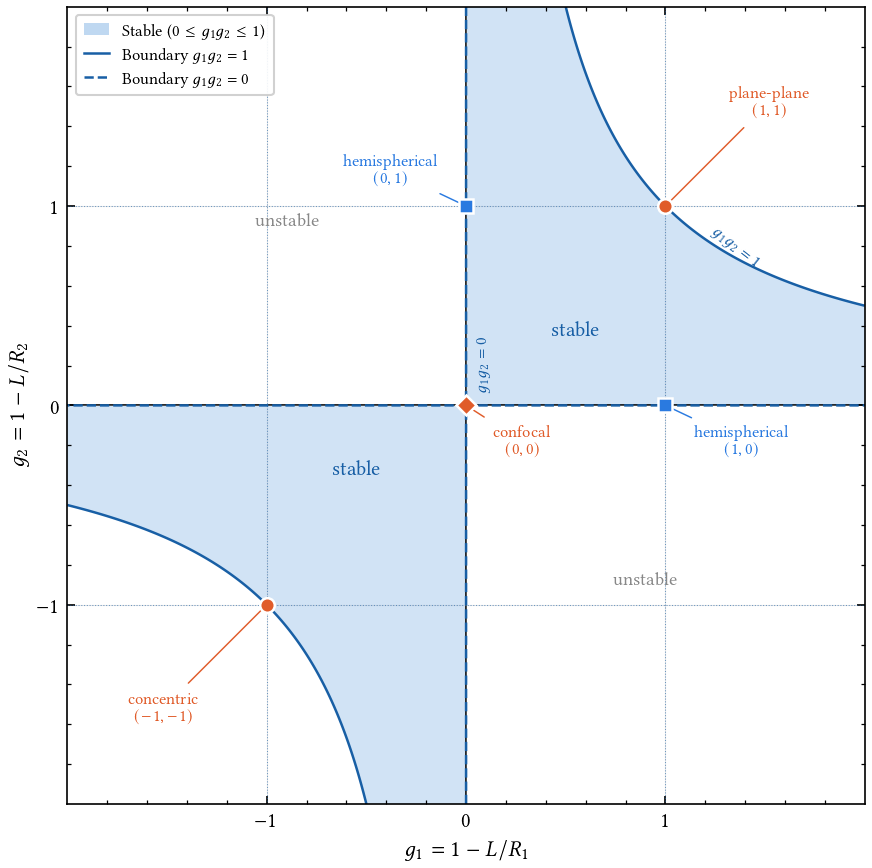

In [5]:
# Figure and axes
set_plot_style(width_frac=1.0)
fig, ax = plt.subplots(figsize=(6, 6))

# Stable region shading
ax.contourf(G1, G2, product,
            levels=[-1e-6, 1 + 1e-6],
            colors=["#4a90d9"],
            alpha=0.25)

# Boundary contours: g1*g2 = 0 (dashed) and g1*g2 = 1 (solid)
line_style_0 = "--"
line_style_1 = "-"
ax.contour(G1, G2, product,
           levels=[0, 1],
           colors=["#185fa5"],
           linewidths=1.2,
           linestyles=[line_style_0, line_style_1])

# Cartesian axes
ax.axhline(0, color="k", linewidth=0.8, zorder=1)
ax.axvline(0, color="k", linewidth=0.8, zorder=1)

# g = ±1 reference grid lines
for v in (-1, 1):
    ax.axhline(v, color="#185fa5", linewidth=0.5, linestyle=":", alpha=0.6)
    ax.axvline(v, color="#185fa5", linewidth=0.5, linestyle=":", alpha=0.6)

# Stable / unstable region text labels
ax.text( 0.55,  0.35, "stable",   ha="center", fontstyle="italic",
         color="#185fa5", fontsize=10)
ax.text(-0.55, -0.35, "stable",   ha="center", fontstyle="italic",
         color="#185fa5", fontsize=10)
ax.text( 0.9,  -0.9,  "unstable", ha="center", fontstyle="italic",
         color="#888",    fontsize=9)
ax.text(-0.9,   0.9,  "unstable", ha="center", fontstyle="italic",
         color="#888",    fontsize=9)

# Hyperbola boundary labels
ax.text(1.22,  0.70, r"$g_1 g_2 = 1$",
        fontsize=8, color="#185fa5", rotation=-38)
ax.text(0.04,  0.08, r"$g_1 g_2 = 0$",
        fontsize=8, color="#185fa5", rotation=90)

# Special cavity points and annotations
for label, (x, y, color, marker) in configs.items():

    ax.plot(
        x, y,
        marker=marker,
        color=color,
        markersize=7,
        markeredgewidth=1.2,
        markeredgecolor="white",
        zorder=5
    )

    dx, dy = offsets[label]

    ax.annotate(
        label,
        xy=(x, y),
        xytext=(x + dx, y + dy),

        fontsize=8,
        color=color,

        ha="center",   # centered horizontally
        va="center",   # centered vertically

        arrowprops=dict(
            arrowstyle="-",
            color=color,
            lw=0.7,
            shrinkA=3,
            shrinkB=4
        )
    )

# Axes formatting
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_xlabel(r"$g_1 = 1 - L/R_1$", fontsize=11)
ax.set_ylabel(r"$g_2 = 1 - L/R_2$", fontsize=11)
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.tick_params(labelsize=10)
ax.set_aspect("equal")
# ax.spines[["top", "right"]].set_visible(False)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#4a90d9", alpha=0.35,
                   label=r"Stable  ($0 \leq g_1 g_2 \leq 1$)"),
    Line2D([0], [0], color="#185fa5", lw=1.2,
           linestyle=line_style_1,  label=r"Boundary  $g_1 g_2 = 1$"),
    Line2D([0], [0], color="#185fa5", lw=1.2,
           linestyle=line_style_0, label=r"Boundary  $g_1 g_2 = 0$"),
]
ax.legend(handles=legend_elements, fontsize=8,
          loc="upper left", framealpha=0.9, edgecolor="#ccc")

plt.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [6]:
# save to svg
fig.savefig("stability-diagram.svg", dpi=300)